In [1]:
#import the tensorflow library and Keras utilities
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

/Users/sita/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
#load the MNIST dataset
data = datasets.mnist
(ip_train, op_train), (ip_test, op_test) = data.load_data()

In [4]:
#reshaping the input data to include channel dimension
ip_train = ip_train.reshape((60000, 28, 28, 1))
ip_test = ip_test.reshape((10000, 28, 28, 1))   
print("Training input shape:", ip_train.shape)
print("Test input shape:", ip_test.shape)

Training input shape: (60000, 28, 28, 1)
Test input shape: (10000, 28, 28, 1)


In [5]:
#prepare the data 
ip_train, ip_test = ip_train / 255.0, ip_test / 255.0

In [6]:
#build the convolutional neural network model
model = models.Sequential()
model.add(layers.Conv2D(30, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(60, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(90, (3, 3), activation='relu'))



/Users/sita/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
#add the final dense layers, dropout layer and output layer
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

In [8]:
#compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
#view the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 30)     │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 60)     │        16,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 60)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 90)       │        48,690 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 810)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        51,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,804 (460.17 KB)

 Trainable params: 117,804 (460.17 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
#tain the model
model.fit(ip_train, op_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8217 - loss: 0.5471
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9748 - loss: 0.0905
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9825 - loss: 0.0600
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9865 - loss: 0.0473
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9896 - loss: 0.0377


In [14]:
#test the model
model.evaluate(ip_test, op_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9888 - loss: 0.0362


[0.02733124978840351, 0.991599977016449]

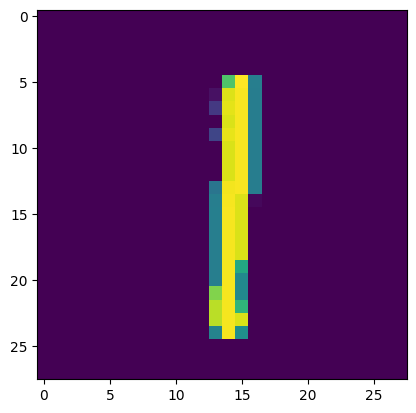

In [17]:
#carry out inference on new data
import matplotlib.pyplot as plt
%matplotlib inline

test_image = ip_test[180]   
#plot the test image
plt.imshow(test_image.reshape(28,28))

In [18]:
import numpy as np
from tensorflow.keras.preprocessing import image

#convert the test image to array and reshape it to include batch dimension
test_image = image.img_to_array(test_image)
test_image = test_image.reshape((1, 28, 28, 1))

#allo the model to predict the class of the test image

In [19]:
#round off results and find max value among them 
result = model.predict(test_image)
result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


array([[1.9577417e-14, 1.0000000e+00, 6.7472855e-10, 6.1275014e-13,
        1.1274518e-09, 9.1894782e-12, 7.9863781e-12, 4.9294574e-10,
        1.2232539e-09, 7.2050664e-12]], dtype=float32)

In [20]:
np.argmax(result)  #predicted class
(np.around(result)).argmax()  #predicted class

np.int64(1)